In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from datetime import datetime
import lightgbm as lgb
import optuna

In [16]:
df = pd.read_csv('consumption_temp.csv')
df.head(5)

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


In [17]:
TEST_DAYS = 14
VALIDATION_DAYS = 14

In [18]:
def preprocess_data(df):
    """Basic preprocessing: drop Helsingfors, convert time, set index, sort."""
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["time"])

    # normalize location strings
    df["location"] = df["location"].astype(str).str.strip().str.lower()

    # keep only Norwegian locations
    norwegian = ["bergen", "oslo", "stavanger", "tromsø", "trondheim"]
    df = df[df["location"].isin(norwegian)].copy()

    df = df.set_index("datetime").sort_index()
    df = df.drop(columns=["time"])

    return df

In [19]:
norw_df = preprocess_data(df)
norw_df.head(5)

,location,consumption,temperature
datetime,,,
2022-04-07 21:00:00,bergen,1.113325,-0.3
2022-04-07 21:00:00,oslo,4.092830,1.0
2022-04-07 21:00:00,stavanger,2.057858,1.3
2022-04-07 21:00:00,tromsø,1.246582,-3.9
2022-04-07 21:00:00,trondheim,1.970098,-2.8


Location

location — pass as a native LightGBM categorical (use categorical_feature param or set the column dtype to category). Don't one-hot encode; LGBM handles it more efficiently internally.

Calendar / time features

hour_sin, hour_cos — cyclical encoding of hour (period 24). Keep these since you're already using them and they help the model understand that hour 23 is close to hour 0.
dow_sin, dow_cos — cyclical encoding of day-of-week (period 7).
month_sin, month_cos — cyclical encoding of month (period 12).
is_weekend — binary, 0/1.
is_holiday — binary, 0/1. Use the holidays library for Norway (NO). This is probably your single highest-value missing feature.
days_to_nearest_holiday — integer, capped at something like 7 or 10. Captures lead-up and wind-down effects (people change consumption behavior around holidays, not just on the day itself).
day_of_year — raw integer 1–365. Gives the model a finer-grained seasonal signal than month alone, and LGBM can split on it directly.

Drop woy_sin/woy_cos — week-of-year is largely redundant with day_of_year and month, and removing it reduces noise.
Temperature features (all available at forecast time)

temperature — raw forecast temperature for the target hour. This is your single most important exogenous feature.
temperature_squared — temperature ** 2. Captures the nonlinear relationship (consumption rises steeply at low temps, flattens in the mild range).
heating_degree_18 — max(0, 18 - temperature). Keep this, it's a well-established energy feature.
cooling_degree_18 — max(0, temperature - 18). Marginal in Norway but costs nothing and helps in warm summers.
temp_delta_24h — temperature - temp_lag_24. Captures whether it's getting colder or warmer compared to yesterday. Since temperature forecasts are available, this is safe to compute.
temp_roll_mean_24 — rolling 24h mean of temperature (shifted by 1 to avoid including the current hour).
temp_roll_mean_168 — rolling 7-day mean of temperature. Captures the longer-term thermal regime.
temp_roll_std_24 — rolling 24h std of temperature. Captures weather volatility.
temp_daily_range — max temp minus min temp for the forecast day. You'll need to compute this from the 24h forecast block. Helps distinguish stable vs. volatile weather days.

Drop temp_lag_24, temp_lag_168, temp_roll_std_168 — these are somewhat redundant with the above and add feature bloat.
Consumption lag features (respecting 5-day / 120h delay)

lag_120 — consumption 5 days ago, same hour. Your earliest available observation.
lag_168 — consumption 7 days ago, same hour. Same weekday, so captures weekly pattern.
lag_336 — consumption 14 days ago, same hour. Two-weeks-ago same weekday.
lag_168_diff — lag_168 - lag_336. Week-over-week change in same-weekday consumption. Tells the model whether demand is trending up or down.
lag_120_168_diff — lag_120 - lag_168. Difference between 5-day-ago and 7-day-ago. Captures very recent trend in the available data.
avail_roll_mean_168 — rolling 7-day mean of consumption.shift(120). General recent level.
avail_roll_mean_336 — rolling 14-day mean of consumption.shift(120). Longer baseline level.
avail_roll_std_168 — rolling 7-day std of consumption.shift(120). Captures recent volatility.

Drop avail_roll_std_336 — the 14-day std is very smooth and adds little over the 7-day version.
Interaction features

heating_degree_x_hour_sin — heating_degree_18 * hour_sin. Captures the fact that heating demand has a different hourly profile than base consumption (peaks in morning/evening).
heating_degree_x_is_weekend — heating_degree_18 * is_weekend. Heating patterns differ on weekends (people home during the day).

Also location degrees - north

In [20]:
def add_location_standardization(data, target_col="consumption", delay_days=5):
    """
    Z-score normalize consumption per location using only available (delayed) data.
    Returns the dataframe with a new target column and the stats needed to invert.
    """
    delay_h = delay_days * 24
    out = data.copy()

    grp = out.groupby("location")[target_col]
    shifted = grp.shift(delay_h)

    out["_loc_mean"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).mean()
    )
    out["_loc_std"] = shifted.groupby(out["location"]).transform(
        lambda x: x.expanding(min_periods=168).std()
    )

    out["consumption_z"] = (out[target_col] - out["_loc_mean"]) / out["_loc_std"]

    return out


def invert_standardization(predictions_df, data):
    """Convert z-score predictions back to MW using the stored location stats."""
    out = predictions_df.copy()
    stats = data[["location", "_loc_mean", "_loc_std"]].copy()
    stats["timestamp"] = stats.index
    out = out.merge(
        stats[["timestamp", "location", "_loc_mean", "_loc_std"]],
        on=["timestamp", "location"],
        how="left",
    )
    out["y_pred_mw"] = out["y_pred"] * out["_loc_std"] + out["_loc_mean"]
    out["y_true_mw"] = out["y_true"] * out["_loc_std"] + out["_loc_mean"]
    return out

In [21]:
def add_features(df, delay_days=5):
    """
    Feature engineering for global Norwegian consumption model.
    Expects standardization (consumption_z, _loc_mean, _loc_std) already applied.
    """
    out = df.copy()
    delay_h = delay_days * 24

    # ══════════════════════════════════════════
    # Location
    # ══════════════════════════════════════════
    out["location"] = out["location"].astype("category")

    lat_map = {
        "bergen": 60.39, "oslo": 59.91, "stavanger": 58.97,
        "tromsø": 69.65, "trondheim": 63.43,
    }
    out["latitude"] = out["location"].map(lat_map)

    # ══════════════════════════════════════════
    # Calendar / time
    # ══════════════════════════════════════════
    hour = out.index.hour
    dow = out.index.dayofweek

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["hour"] = hour
    out["dow"] = dow
    #out["is_weekend"] = (dow >= 5).astype(int)
    out["day_of_year"] = out.index.dayofyear

    # ══════════════════════════════════════════
    # Temperature features
    # ══════════════════════════════════════════
    out["heating_degree_18"] = np.maximum(0.0, 18.0 - out["temperature"])

    # Rolling means (shifted by 1 to avoid current hour)
    shifted_temp = out.groupby("location")["temperature"].shift(1)
    out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(24, min_periods=24).mean()
    )
    out["temp_roll_mean_168"] = shifted_temp.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    # out["temp_roll_std_24"] = shifted_temp.groupby(out["location"]).transform(
    #     lambda x: x.rolling(24, min_periods=24).std()
    # )

    out["temp_delta_24h"] = out["temperature"] - out.groupby("location")["temperature"].shift(24)

    # Day-level summary (full forecast available)
    out["_date"] = out.index.date
    out["temp_day_mean"] = out.groupby(["location", "_date"])["temperature"].transform("mean")
    out.drop(columns=["_date"], inplace=True)

    # ── Same-hour temperature averages (key insight from reference) ──
    # "What was the temperature at this exact hour, averaged over past X days?"
    # These were the TOP features in the reference model.
    # Temperature forecasts are available, so all shifts are valid.
    temp_1d = out.groupby("location")["temperature"].shift(24)
    temp_3d = (temp_1d
               + out.groupby("location")["temperature"].shift(48)
               + out.groupby("location")["temperature"].shift(72)) / 3.0
    temp_7d = sum(out.groupby("location")["temperature"].shift(24 * d)
                  for d in range(1, 8)) / 7.0
    temp_14d = sum(out.groupby("location")["temperature"].shift(24 * d)
                   for d in range(1, 15)) / 14.0

    out["temp_at_time_1d"] = temp_1d
    out["avg_temp_at_time_3d"] = temp_3d
    out["avg_temp_at_time_7d"] = temp_7d
    out["avg_temp_at_time_14d"] = temp_14d

    # ══════════════════════════════════════════
    # Consumption lag features (from consumption_z)
    # ══════════════════════════════════════════
    grp_z = out.groupby("location")["consumption_z"]

    out["lag_120"] = grp_z.shift(120)   # 5 days ago, same hour
    out["lag_168"] = grp_z.shift(168)   # 7 days ago, same hour
    out["lag_336"] = grp_z.shift(336)   # 14 days ago, same hour

    out["lag_168_diff"] = out["lag_168"] - out["lag_336"]
    out["lag_120_168_diff"] = out["lag_120"] - out["lag_168"]

    # ── Same-hour consumption averages over available ranges ──
    # avg consumption at this hour, days 5-7 ago
    out["avg_cons_at_time_5_7d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 8)
    ) / 3.0

    # avg consumption at this hour, days 5-11 ago
    out["avg_cons_at_time_5_11d"] = sum(
        grp_z.shift(24 * d) for d in range(5, 12)
    ) / 7.0

    # Rolling stats on available consumption
    avail_z = grp_z.shift(delay_h)
    out["avail_roll_mean_168"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=168).mean()
    )
    out["avail_roll_mean_336"] = avail_z.groupby(out["location"]).transform(
        lambda x: x.rolling(336, min_periods=336).mean()
    )
    # out["avail_roll_std_168"] = avail_z.groupby(out["location"]).transform(
    #     lambda x: x.rolling(168, min_periods=168).std()
    # )

    # ══════════════════════════════════════════
    # Recent drift
    # ══════════════════════════════════════════
    week_change = (
        out.groupby("location")["consumption_z"].shift(delay_h)
        - out.groupby("location")["consumption_z"].shift(delay_h + 168)
    )
    out["recent_drift_mean_7d"] = week_change.groupby(out["location"]).transform(
        lambda x: x.rolling(168, min_periods=24).mean()
    )

    return out

In [22]:
cons_z = add_location_standardization(norw_df)
feature_df = add_features(cons_z)
# drop rows with NaNs (due to rolling windows and lags)
data = feature_df.copy().dropna()
data.head(2)

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/4015589271.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted_temp = out.groupby("location")["temperature"].shift(1)
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/4015589271.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["temp_roll_mean_24"] = shifted_temp.groupby(out["location"]).transform(
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/4015589271.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

,location,consumption,temperature,_loc_mean,_loc_std,consumption_z,latitude,hour_sin,hour_cos,dow_sin,...,lag_120,lag_168,lag_336,lag_168_diff,lag_120_168_diff,avg_cons_at_time_5_7d,avg_cons_at_time_5_11d,avail_roll_mean_168,avail_roll_mean_336,recent_drift_mean_7d
datetime,,,,,,,,,,,,,,,,,,,,,
2022-05-08 19:00:00,bergen,0.908972,8.0,0.820844,0.158947,0.554449,60.39,-0.965926,0.258819,-0.781831,...,0.314885,0.097733,-1.128623,1.226355,0.217153,0.258935,0.157062,-0.604792,-1.601372,1.993161
2022-05-08 19:00:00,oslo,2.831582,11.8,2.809865,0.477492,0.045481,59.91,-0.965926,0.258819,-0.781831,...,0.313790,0.286172,-0.258996,0.545168,0.027618,0.248852,0.246411,-0.510144,-1.301784,1.583280


In [23]:
@dataclass
class ForecastSplit:
    """One day-ahead forecast unit."""
    forecast_date: pd.Timestamp      # day D we are predicting
    avail_cutoff: pd.Timestamp       # last hour with known consumption (D-5 23:00)
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame              # for early stopping / tuning evaluation
    y_val: pd.Series
    X_test: pd.DataFrame             # 24h × 5 locations
    y_test: pd.Series


def build_day_ahead_splits(
    data: pd.DataFrame,
    forecast_days: pd.DatetimeIndex,
    target_col: str = "consumption_z",
    val_days: int = 14,
    delay_days: int = 5,
    include_val: bool = True,
) -> list[ForecastSplit]:
    exclude = {target_col, "consumption", "_loc_mean", "_loc_std"}
    feature_cols = [c for c in data.columns if c not in exclude]
    splits = []

    for D in forecast_days:
        D = D.normalize()

        test_start = D
        test_end = D + pd.Timedelta(days=1)
        test_data = data[(data.index >= test_start) & (data.index < test_end)]

        if test_data.empty:
            continue

        avail_day = (D - pd.Timedelta(days=delay_days)).normalize()
        avail_cutoff = avail_day + pd.Timedelta(hours=23)

        available = data[data.index <= avail_cutoff]

        if include_val:
            val_start = (avail_day - pd.Timedelta(days=val_days - 1)).normalize()
            val_data = available[available.index >= val_start]
            train_data = available[available.index < val_start]

            if train_data.empty or val_data.empty:
                continue
        else:
            # All available data goes to training, val is empty
            train_data = available
            val_data = available.iloc[:0]  # empty with correct columns

            if train_data.empty:
                continue

        splits.append(ForecastSplit(
            forecast_date=D,
            avail_cutoff=avail_cutoff,
            X_train=train_data[feature_cols],
            y_train=train_data[target_col],
            X_val=val_data[feature_cols],
            y_val=val_data[target_col],
            X_test=test_data[feature_cols],
            y_test=test_data[target_col],
        ))

    return splits


# ═══════════════════════════════════════════
# Define windows
# ═══════════════════════════════════════════
target_col = "consumption_z"
DELAY_DAYS = 5
TEST_DAYS = 14
VAL_DAYS = 14
TUNE_DAYS = 28

# Last complete day in dataset
last_day = data.index.max().normalize()

# Test: last 14 days
test_end = last_day
test_start = test_end - pd.Timedelta(days=TEST_DAYS - 1)
test_day_range = pd.date_range(test_start, test_end, freq="D")

# Tune: 28 days immediately before test (for hyperparameter search)
tune_end = test_start - pd.Timedelta(days=1)
tune_start = tune_end - pd.Timedelta(days=TUNE_DAYS - 1)
tune_day_range = pd.date_range(tune_start, tune_end, freq="D")

# Tune splits need val for early stopping
tune_splits = build_day_ahead_splits(
    data, tune_day_range, val_days=VAL_DAYS, delay_days=DELAY_DAYS, include_val=True
)

# Test splits use ALL available data for training
test_splits = build_day_ahead_splits(
    data, test_day_range, delay_days=DELAY_DAYS, include_val=False
)


# ═══════════════════════════════════════════
# Leakage & sanity checks
# ═══════════════════════════════════════════
assert tune_splits[-1].forecast_date + pd.Timedelta(days=1) == test_splits[0].forecast_date, \
    "Tune and test windows must be adjacent."

for label, splits, has_val in [("TUNE", tune_splits, True), ("TEST", test_splits, False)]:
    for s in splits:
        D = s.forecast_date
        gap_start = (D - pd.Timedelta(days=DELAY_DAYS - 1)).normalize()

        # Train must not enter the unavailable gap
        assert s.X_train.index.max() < gap_start, \
            f"LEAK {label} D={D.date()}: train goes to {s.X_train.index.max()}, gap starts {gap_start}"

        # Train must end at or before avail cutoff
        assert s.X_train.index.max() <= s.avail_cutoff, \
            f"LEAK {label} D={D.date()}: train extends past availability"

        if has_val:
            # Val must not enter the unavailable gap
            assert s.X_val.index.max() < gap_start, \
                f"LEAK {label} D={D.date()}: val goes to {s.X_val.index.max()}, gap starts {gap_start}"

            # Val must end at or before avail cutoff
            assert s.X_val.index.max() <= s.avail_cutoff, \
                f"LEAK {label} D={D.date()}: val extends past availability"

            # Train must end before val starts
            assert s.X_train.index.max() < s.X_val.index.min(), \
                f"LEAK {label} D={D.date()}: train overlaps with val"

    # Verify expanding window: last split has more train data than first
    assert len(splits[-1].y_train) >= len(splits[0].y_train), \
        f"{label}: training window is not expanding"

    s0, sN = splits[0], splits[-1]
    print(f"{label} window: {s0.forecast_date.date()} → {sN.forecast_date.date()} ({len(splits)} days)")
    print(f"  first: avail={s0.avail_cutoff.date()}, "
          f"train={len(s0.y_train):,} rows, val={len(s0.y_val):,}, test={len(s0.y_test):,}")
    print(f"  last:  avail={sN.avail_cutoff.date()}, "
          f"train={len(sN.y_train):,} rows, val={len(sN.y_val):,}, test={len(sN.y_test):,}")
    print()

TUNE window: 2023-02-20 → 2023-03-19 (28 days)
  first: avail=2023-02-15, train=32,305 rows, val=1,680, test=120
  last:  avail=2023-03-14, train=35,545 rows, val=1,680, test=120

TEST window: 2023-03-20 → 2023-04-02 (14 days)
  first: avail=2023-03-15, train=37,345 rows, val=0, test=120
  last:  avail=2023-03-28, train=38,905 rows, val=0, test=110



In [24]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

target_col = "consumption_z"
exclude = {"consumption", "consumption_z", "_loc_mean", "_loc_std"}
feature_cols = [c for c in data.columns if c not in exclude]
cat_features = ["location"]

# Build monotone constraints based on feature column order
def build_monotone_constraints(feature_cols):
    constraints = []
    for col in feature_cols:
        if col == "temperature":
            constraints.append(-1)       # higher temp → lower consumption (heating)
        elif col == "heating_degree_18":
            constraints.append(1)        # higher heating degree → higher consumption
        elif col == "avg_temp_at_time_7d":
            constraints.append(-1)       # same logic as temperature
        elif col == "temp_day_mean":
            constraints.append(-1)
        elif col == "temp_roll_mean_168":
            constraints.append(-1)
        else:
            constraints.append(0)        # unconstrained
    return constraints

monotone_constraints = build_monotone_constraints(feature_cols)


def make_model(params: dict) -> lgb.LGBMRegressor:
    base = dict(
        objective="regression_l1",
        boosting_type="gbdt",
        n_estimators=2000,
        bagging_freq=1,
        linear_tree=True,  # linear models in leaves
        # monotone_constraints=monotone_constraints, # can't be used in L1 obj
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    base.update(params)
    return lgb.LGBMRegressor(**base)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0

# def time_weights(index, halflife_days=120):
#     """Exponential decay: most recent row = 1.0, older rows decay."""
#     days_ago = (index.max() - index).total_seconds().values / 86400
#     return np.exp(-np.log(2) * days_ago / halflife_days)

In [25]:
def objective(trial: optuna.Trial) -> float:
    # Build monotone constraints: temperature and heating_degree should be
    # monotonically related to consumption. We need to map feature indices.
    # For now, pass as a param — we'll build the constraint vector below.

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 31),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_samples": trial.suggest_int("min_child_samples", 30, 150),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),

        # New parameters
        "path_smooth": trial.suggest_float("path_smooth", 0.0, 10.0),
        "extra_trees": trial.suggest_categorical("extra_trees", [True, False]),
        #"extra_trees": False, 
    }

    tune_subset = tune_splits[::4]
    scores = []
    best_iters = []

    for step, split in enumerate(tune_subset):
        model = make_model({**params, "n_estimators": 1000})
        model.fit(
            split.X_train, split.y_train,
            eval_set=[(split.X_val, split.y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(30, verbose=False)],
            categorical_feature=cat_features,
        )
        best_iters.append(model.best_iteration_)
        y_pred = model.predict(split.X_val)
        scores.append(mae(split.y_val.values, y_pred))

        trial.report(np.mean(scores), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr("median_best_iter", int(np.median(best_iters)))
    return float(np.mean(scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

In [26]:
best_params = study.best_trial.params
best_n_estimators = study.best_trial.user_attrs["median_best_iter"]

print(f"\nBest tune MAE: {study.best_value:.4f}")
print(f"Best params:   {best_params}")
print(f"Best n_estimators (median early stop): {best_n_estimators}")


Best tune MAE: 0.1343
Best params:   {'learning_rate': 0.030689211813766895, 'num_leaves': 7, 'max_depth': 5, 'min_child_samples': 72, 'reg_lambda': 0.7859972242852454, 'reg_alpha': 7.7323809832431225, 'subsample': 0.6907937821798633, 'colsample_bytree': 0.7962899236743513, 'path_smooth': 9.312847896212155, 'extra_trees': True}
Best n_estimators (median early stop): 170


In [27]:
# ═══════════════════════════════════════════════
# Define diverse model configs
# ═══════════════════════════════════════════════

# Feature subsets
exclude_base = {"consumption", "consumption_z", "_loc_mean", "_loc_std"}
all_features = [c for c in data.columns if c not in exclude_base]

lag_features = [c for c in all_features if any(x in c for x in [
    "lag_", "avail_", "avg_cons", "drift", "location", "latitude",
    "hour", "dow", "is_weekend", "day_of_year"
])]

temp_features = [c for c in all_features if any(x in c for x in [
    "temperature", "temp_", "heating_", "avg_temp",
    "location", "latitude", "hour", "dow", "is_weekend", "day_of_year", "daylight"
])]


def make_model_config(objective, linear_tree, extra_params, feature_subset, name):
    return {
        "name": name,
        "objective": objective,
        "linear_tree": linear_tree,
        "extra_params": extra_params,
        "features": feature_subset,
    }


ensemble_configs = [
    # Model A: current best
    make_model_config(
        objective="regression_l1",
        linear_tree=True,
        extra_params={**best_params},
        feature_subset=all_features,
        name="A: Linear L1 (full)",
    ),
    # Model B: lag-only, standard trees, L2
    make_model_config(
        objective="regression",
        linear_tree=False,
        extra_params={
            "num_leaves": 31, "max_depth": 5, "min_child_samples": 50,
            "reg_lambda": 1.0, "reg_alpha": 1.0,
            "subsample": 0.7, "colsample_bytree": 0.7,
            "learning_rate": 0.05,
        },
        feature_subset=lag_features,
        name="B: Standard L2 (lags only)",
    ),
    # Model C: temp-only, linear trees, Huber
    make_model_config(
        objective="huber",
        linear_tree=True,
        extra_params={
            "num_leaves": 15, "max_depth": 4, "min_child_samples": 50,
            "reg_lambda": 1.0, "reg_alpha": 1.0,
            "subsample": 0.8, "colsample_bytree": 0.8,
            "learning_rate": 0.05, "alpha": 0.9,  # Huber delta
        },
        feature_subset=temp_features,
        name="C: Linear Huber (temp only)",
    ),
    # Model D: very shallow stabilizer
    make_model_config(
        objective="regression_l1",
        linear_tree=False,
        extra_params={
            "num_leaves": 4, "max_depth": 2, "min_child_samples": 100,
            "reg_lambda": 5.0, "reg_alpha": 5.0,
            "subsample": 0.8, "colsample_bytree": 0.8,
            "learning_rate": 0.1,
        },
        feature_subset=all_features,
        name="D: Shallow stabilizer",
    ),
]


# ═══════════════════════════════════════════════
# Train and predict with each model
# ═══════════════════════════════════════════════
def train_diverse_model(config, X_train, y_train):
    base = dict(
        objective=config["objective"],
        boosting_type="gbdt",
        n_estimators=best_n_estimators,
        bagging_freq=1,
        linear_tree=config["linear_tree"],
        extra_trees=True if config["linear_tree"] else False,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    base.update(config["extra_params"])
    model = lgb.LGBMRegressor(**base)

    # Select only the features this model uses
    feature_cols = config["features"]
    model.fit(X_train[feature_cols], y_train, categorical_feature=["location"])
    return model, feature_cols

In [45]:
# ═══════════════════════════════════════════════
# Test backtest — evaluate each model alone + blended
# ═══════════════════════════════════════════════
pred_rows = []
daily_rows = []
per_model_preds = {cfg["name"]: [] for cfg in ensemble_configs}

# Equal weights to start — tune after seeing individual performance
weights = {cfg["name"]: 1.0 / len(ensemble_configs) for cfg in ensemble_configs}

print("Running diverse ensemble backtest\n")

for i, split in enumerate(test_splits, start=1):
    model_predictions = {}

    for config in ensemble_configs:
        model, feat_cols = train_diverse_model(config, split.X_train, split.y_train)
        pred = model.predict(split.X_test[feat_cols])
        model_predictions[config["name"]] = pred

    # Weighted blend
    y_pred = sum(weights[name] * pred for name, pred in model_predictions.items())
    y_true = split.y_test.values

    day_mae = mae(y_true, y_pred)
    day_rmse = rmse(y_true, y_pred)

    daily_rows.append({
        "forecast_date": split.forecast_date,
        "MAE": day_mae,
        "RMSE": day_rmse,
        "SMAPE_%": smape(y_true, y_pred),
    })

    pred_rows.append(pd.DataFrame({
        "forecast_date": split.forecast_date,
        "timestamp": split.X_test.index,
        "location": split.X_test["location"].values,
        "y_true": y_true,
        "y_pred": y_pred,
        **{f"pred_{name}": pred for name, pred in model_predictions.items()},
    }))

    print(f"  Day {i:>2}/{len(test_splits)}  {split.forecast_date.date()}  "
          f"MAE={day_mae:.4f}  RMSE={day_rmse:.4f}")


predictions_ens = pd.concat(pred_rows, ignore_index=True)
predictions_ens = invert_standardization(predictions_ens, data)

daily_metrics_ens = pd.DataFrame([{
    "forecast_date": D,
    "MAE": mae(grp["y_true_mw"], grp["y_pred_mw"]),
    "RMSE": rmse(grp["y_true_mw"], grp["y_pred_mw"]),
    "SMAPE_%": smape(grp["y_true_mw"], grp["y_pred_mw"]),
} for D, grp in predictions_ens.groupby("forecast_date")])

print(f"\n{'='*50}")
print(f"Ensemble SMAPE:      {daily_metrics_ens['SMAPE_%'].mean():.2f}%")
daily_metrics = daily_metrics_ens.copy()  # For now, we only have the ensemble predictions
#print(f"Single global SMAPE: {daily_metrics['SMAPE_%'].mean():.2f}%")

Running diverse ensemble backtest

  Day  1/14  2023-03-20  MAE=0.2032  RMSE=0.2230
  Day  2/14  2023-03-21  MAE=0.1708  RMSE=0.2064
  Day  3/14  2023-03-22  MAE=0.2197  RMSE=0.2473
  Day  4/14  2023-03-23  MAE=0.1970  RMSE=0.2420
  Day  5/14  2023-03-24  MAE=0.1813  RMSE=0.1993
  Day  6/14  2023-03-25  MAE=0.1451  RMSE=0.1972
  Day  7/14  2023-03-26  MAE=0.1505  RMSE=0.1883
  Day  8/14  2023-03-27  MAE=0.1621  RMSE=0.1923
  Day  9/14  2023-03-28  MAE=0.1381  RMSE=0.1705
  Day 10/14  2023-03-29  MAE=0.1583  RMSE=0.1958
  Day 11/14  2023-03-30  MAE=0.2055  RMSE=0.2604
  Day 12/14  2023-03-31  MAE=0.1852  RMSE=0.2306
  Day 13/14  2023-04-01  MAE=0.1471  RMSE=0.2014
  Day 14/14  2023-04-02  MAE=0.1457  RMSE=0.1808

Ensemble SMAPE:      6.29%


In [29]:
# ═══════════════════════════════════════════════
# Per-model diagnostics
# ═══════════════════════════════════════════════
print("\nPer-model SMAPE (individual performance):\n")

for name in [cfg["name"] for cfg in ensemble_configs]:
    pred_col = f"pred_{name}"
    if pred_col not in predictions_ens.columns:
        continue

    # Need to invert each model's predictions individually
    temp = predictions_ens.copy()
    temp["y_pred_mw_individual"] = temp[pred_col] * temp["_loc_std"] + temp["_loc_mean"]

    overall = smape(temp["y_true_mw"], temp["y_pred_mw_individual"])

    per_loc = {}
    for loc in sorted(temp["location"].unique()):
        loc_data = temp[temp["location"] == loc]
        per_loc[loc] = smape(loc_data["y_true_mw"], loc_data["y_pred_mw_individual"])

    print(f"  {name}")
    print(f"    Overall: {overall:.2f}%")
    for loc, val in per_loc.items():
        print(f"    {loc:12s}: {val:.2f}%")
    print()


Per-model SMAPE (individual performance):

  A: Linear L1 (full)
    Overall: 6.68%
    bergen      : 6.11%
    oslo        : 3.81%
    stavanger   : 6.47%
    tromsø      : 8.17%
    trondheim   : 8.85%

  B: Standard L2 (lags only)
    Overall: 11.00%
    bergen      : 11.55%
    oslo        : 12.42%
    stavanger   : 13.74%
    tromsø      : 7.77%
    trondheim   : 9.53%

  C: Linear Huber (temp only)
    Overall: 6.79%
    bergen      : 4.97%
    oslo        : 5.97%
    stavanger   : 9.45%
    tromsø      : 7.58%
    trondheim   : 5.97%

  D: Shallow stabilizer
    Overall: 8.36%
    bergen      : 8.23%
    oslo        : 8.57%
    stavanger   : 8.29%
    tromsø      : 6.33%
    trondheim   : 10.38%



In [30]:
# # Quick ablation — run each with existing best_params, just override one thing
# for name, override in [
#     ("No linear_tree", {"linear_tree": False}),
#     ("No extra_trees", {"extra_trees": False}),
#     ("path_smooth=0", {"path_smooth": 0.0}),
# ]:
#     test_mae = []
#     for split in test_splits:
#         model = make_model({**best_params, "n_estimators": best_n_estimators, **override})
#         model.fit(split.X_train, split.y_train, categorical_feature=cat_features)
#         y_pred = model.predict(split.X_test)
#         test_mae.append(mae(split.y_test.values, y_pred))
#     print(f"{name:25s} — avg z-MAE: {np.mean(test_mae):.4f}")

# print(f"{'Full model':25s} — avg z-MAE: {np.mean([mae(s.y_test.values, make_model({**best_params, 'n_estimators': best_n_estimators}).fit(s.X_train, s.y_train, categorical_feature=cat_features).predict(s.X_test)) for s in test_splits]):.4f}")

In [32]:
predictions = predictions_ens.copy()
predictions.head(5)

,forecast_date,timestamp,location,y_true,y_pred,pred_A: Linear L1 (full),pred_B: Standard L2 (lags only),pred_C: Linear Huber (temp only),pred_D: Shallow stabilizer,_loc_mean,_loc_std,y_pred_mw,y_true_mw
0,2023-03-20,2023-03-20,bergen,0.557130,0.735530,0.658617,1.016561,0.535729,0.731214,1.819931,1.158796,2.672260,2.465531
1,2023-03-20,2023-03-20,oslo,0.529429,0.595300,0.384433,0.993189,0.447050,0.556526,6.642509,4.682266,9.429859,9.121438
2,2023-03-20,2023-03-20,stavanger,0.557530,0.584114,0.525219,1.035095,0.168666,0.607475,3.199466,2.117289,4.436203,4.379918
3,2023-03-20,2023-03-20,tromsø,0.638192,0.836237,0.780358,0.966425,0.632316,0.965850,1.309328,0.556744,1.774899,1.664638
4,2023-03-20,2023-03-20,trondheim,0.710879,0.894698,0.876928,1.026652,0.722140,0.953073,2.215223,1.132421,3.228398,3.020238


In [33]:
# split predictions by location for error analysis
predictions_by_location = {
    loc: df_loc.reset_index(drop=True)
    for loc, df_loc in predictions.groupby("location")
}

# print metrics by location
print("\nMetrics by location:")
for loc, df_loc in predictions.groupby("location"):
    loc_mae = mae(df_loc["y_true_mw"], df_loc["y_pred_mw"])
    loc_rmse = rmse(df_loc["y_true_mw"], df_loc["y_pred_mw"])
    loc_smape = smape(df_loc["y_true_mw"], df_loc["y_pred_mw"])
    print(f"  {loc.capitalize()}: MAE={loc_mae:.4f} MW, RMSE={loc_rmse:.4f} MW, SMAPE={loc_smape:.2f}%")



Metrics by location:
  Bergen: MAE=0.1822 MW, RMSE=0.2164 MW, SMAPE=6.36%
  Oslo: MAE=0.5057 MW, RMSE=0.6198 MW, SMAPE=4.62%
  Stavanger: MAE=0.3724 MW, RMSE=0.4732 MW, SMAPE=7.30%
  Tromsø: MAE=0.1103 MW, RMSE=0.1352 MW, SMAPE=5.89%
  Trondheim: MAE=0.2521 MW, RMSE=0.2831 MW, SMAPE=7.32%


/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/3735928553.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for loc, df_loc in predictions.groupby("location")
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/3735928553.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for loc, df_loc in predictions.groupby("location"):


Baselines

In [34]:
# Precompute lookup once (datetime + location multi-index)
lookup = data.reset_index().set_index(["datetime", "location"])


def evaluate_baseline(name, test_splits, predict_fn):
    """Run a baseline predictor over test splits. Both y_true and y_pred in MW."""
    pred_rows = []
    daily_rows = []

    for split in test_splits:
        locations = split.X_test["location"].values
        timestamps = split.X_test.index

        # Get true values in MW via the lookup (not z-score)
        y_true = np.array([
            lookup.loc[(ts, loc), "consumption"]
            for ts, loc in zip(timestamps, locations)
        ])
        y_pred = predict_fn(split)

        daily_rows.append({
            "forecast_date": split.forecast_date,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "SMAPE_%": smape(y_true, y_pred),
        })

        pred_rows.append(pd.DataFrame({
            "forecast_date": split.forecast_date,
            "timestamp": timestamps,
            "location": locations,
            "y_true": y_true,
            "y_pred": y_pred,
        }))

    metrics = pd.DataFrame(daily_rows)
    preds = pd.concat(pred_rows, ignore_index=True)

    print(f"── {name} ──")
    print(f"   MAE:   {metrics['MAE'].mean():.4f} MW")
    print(f"   RMSE:  {metrics['RMSE'].mean():.4f} MW")
    print(f"   SMAPE: {metrics['SMAPE_%'].mean():.2f}%\n")

    return metrics, preds


def baseline_lag_168(split):
    week_ago = split.X_test.index - pd.Timedelta(hours=168)
    locations = split.X_test["location"].values
    return np.array([
        lookup.loc[(ts, loc), "consumption"]
        for ts, loc in zip(week_ago, locations)
    ])


def baseline_lag_120(split):
    five_days_ago = split.X_test.index - pd.Timedelta(hours=120)
    locations = split.X_test["location"].values
    return np.array([
        lookup.loc[(ts, loc), "consumption"]
        for ts, loc in zip(five_days_ago, locations)
    ])


def baseline_avg_120_168(split):
    locations = split.X_test["location"].values
    lag_5d = np.array([
        lookup.loc[(ts, loc), "consumption"]
        for ts, loc in zip(split.X_test.index - pd.Timedelta(hours=120), locations)
    ])
    lag_7d = np.array([
        lookup.loc[(ts, loc), "consumption"]
        for ts, loc in zip(split.X_test.index - pd.Timedelta(hours=168), locations)
    ])
    return (lag_5d + lag_7d) / 2.0


lag168_metrics, lag168_preds = evaluate_baseline(
    "Lag 168h (same weekday last week)", test_splits, baseline_lag_168
)
lag120_metrics, lag120_preds = evaluate_baseline(
    "Lag 120h (5 days ago, earliest available)", test_splits, baseline_lag_120
)
avg_metrics, avg_preds = evaluate_baseline(
    "Average of lag 120h + 168h", test_splits, baseline_avg_120_168
)

── Lag 168h (same weekday last week) ──
   MAE:   0.4785 MW
   RMSE:  0.6619 MW
   SMAPE: 9.09%

── Lag 120h (5 days ago, earliest available) ──
   MAE:   0.4864 MW
   RMSE:  0.7116 MW
   SMAPE: 9.43%

── Average of lag 120h + 168h ──
   MAE:   0.4530 MW
   RMSE:  0.6376 MW
   SMAPE: 8.71%



In [35]:
summary = pd.DataFrame({
    "Baseline": [
        "Lag 168h (same weekday)",
        "Lag 120h (5 days ago)",
        "Avg lag 120h + 168h",
        "LGBM (tuned)",
    ],
    "MAE": [
        lag168_metrics["MAE"].mean(),
        lag120_metrics["MAE"].mean(),
        avg_metrics["MAE"].mean(),
        daily_metrics["MAE"].mean(),
    ],
    "RMSE": [
        lag168_metrics["RMSE"].mean(),
        lag120_metrics["RMSE"].mean(),
        avg_metrics["RMSE"].mean(),
        daily_metrics["RMSE"].mean(),
    ],
    "SMAPE_%": [
        lag168_metrics["SMAPE_%"].mean(),
        lag120_metrics["SMAPE_%"].mean(),
        avg_metrics["SMAPE_%"].mean(),
        daily_metrics["SMAPE_%"].mean(),
    ],
})

summary = summary.sort_values("MAE").reset_index(drop=True)
display(summary)

,Baseline,MAE,RMSE,SMAPE_%
0,LGBM (tuned),0.284139,0.380616,6.289844
1,Avg lag 120h + 168h,0.453011,0.637559,8.714729
2,Lag 168h (same weekday),0.478533,0.661903,9.090501
3,Lag 120h (5 days ago),0.486363,0.711649,9.425525


evaluate

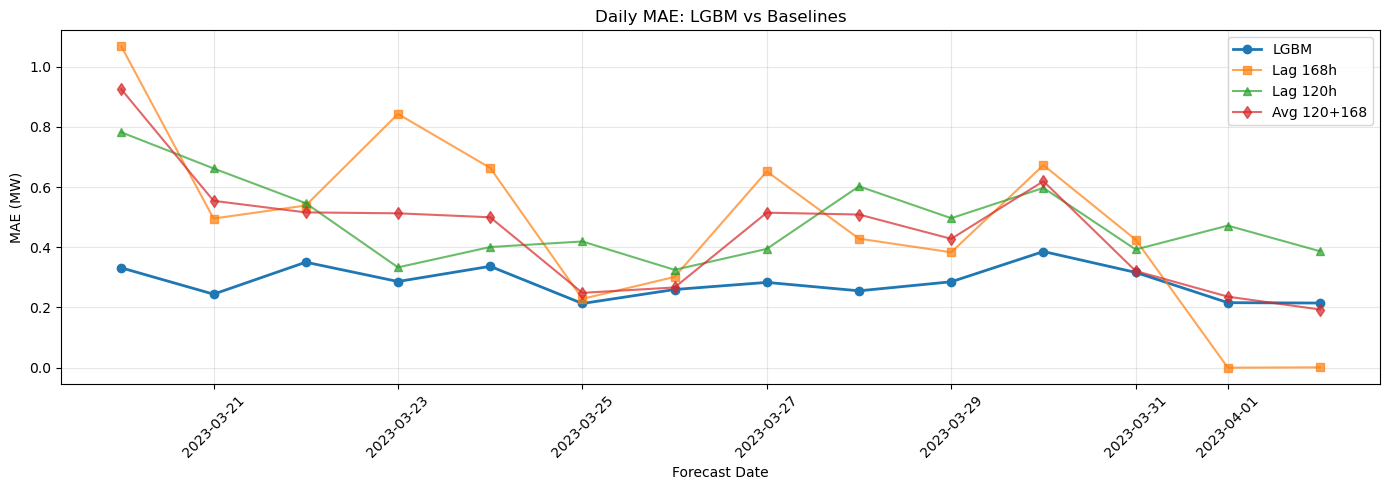

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_metrics["forecast_date"], daily_metrics["MAE"], marker="o", label="LGBM", linewidth=2)
ax.plot(lag168_metrics["forecast_date"], lag168_metrics["MAE"], marker="s", label="Lag 168h", alpha=0.7)
ax.plot(lag120_metrics["forecast_date"], lag120_metrics["MAE"], marker="^", label="Lag 120h", alpha=0.7)
ax.plot(avg_metrics["forecast_date"], avg_metrics["MAE"], marker="d", label="Avg 120+168", alpha=0.7)
ax.set_title("Daily MAE: LGBM vs Baselines")
ax.set_xlabel("Forecast Date")
ax.set_ylabel("MAE (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

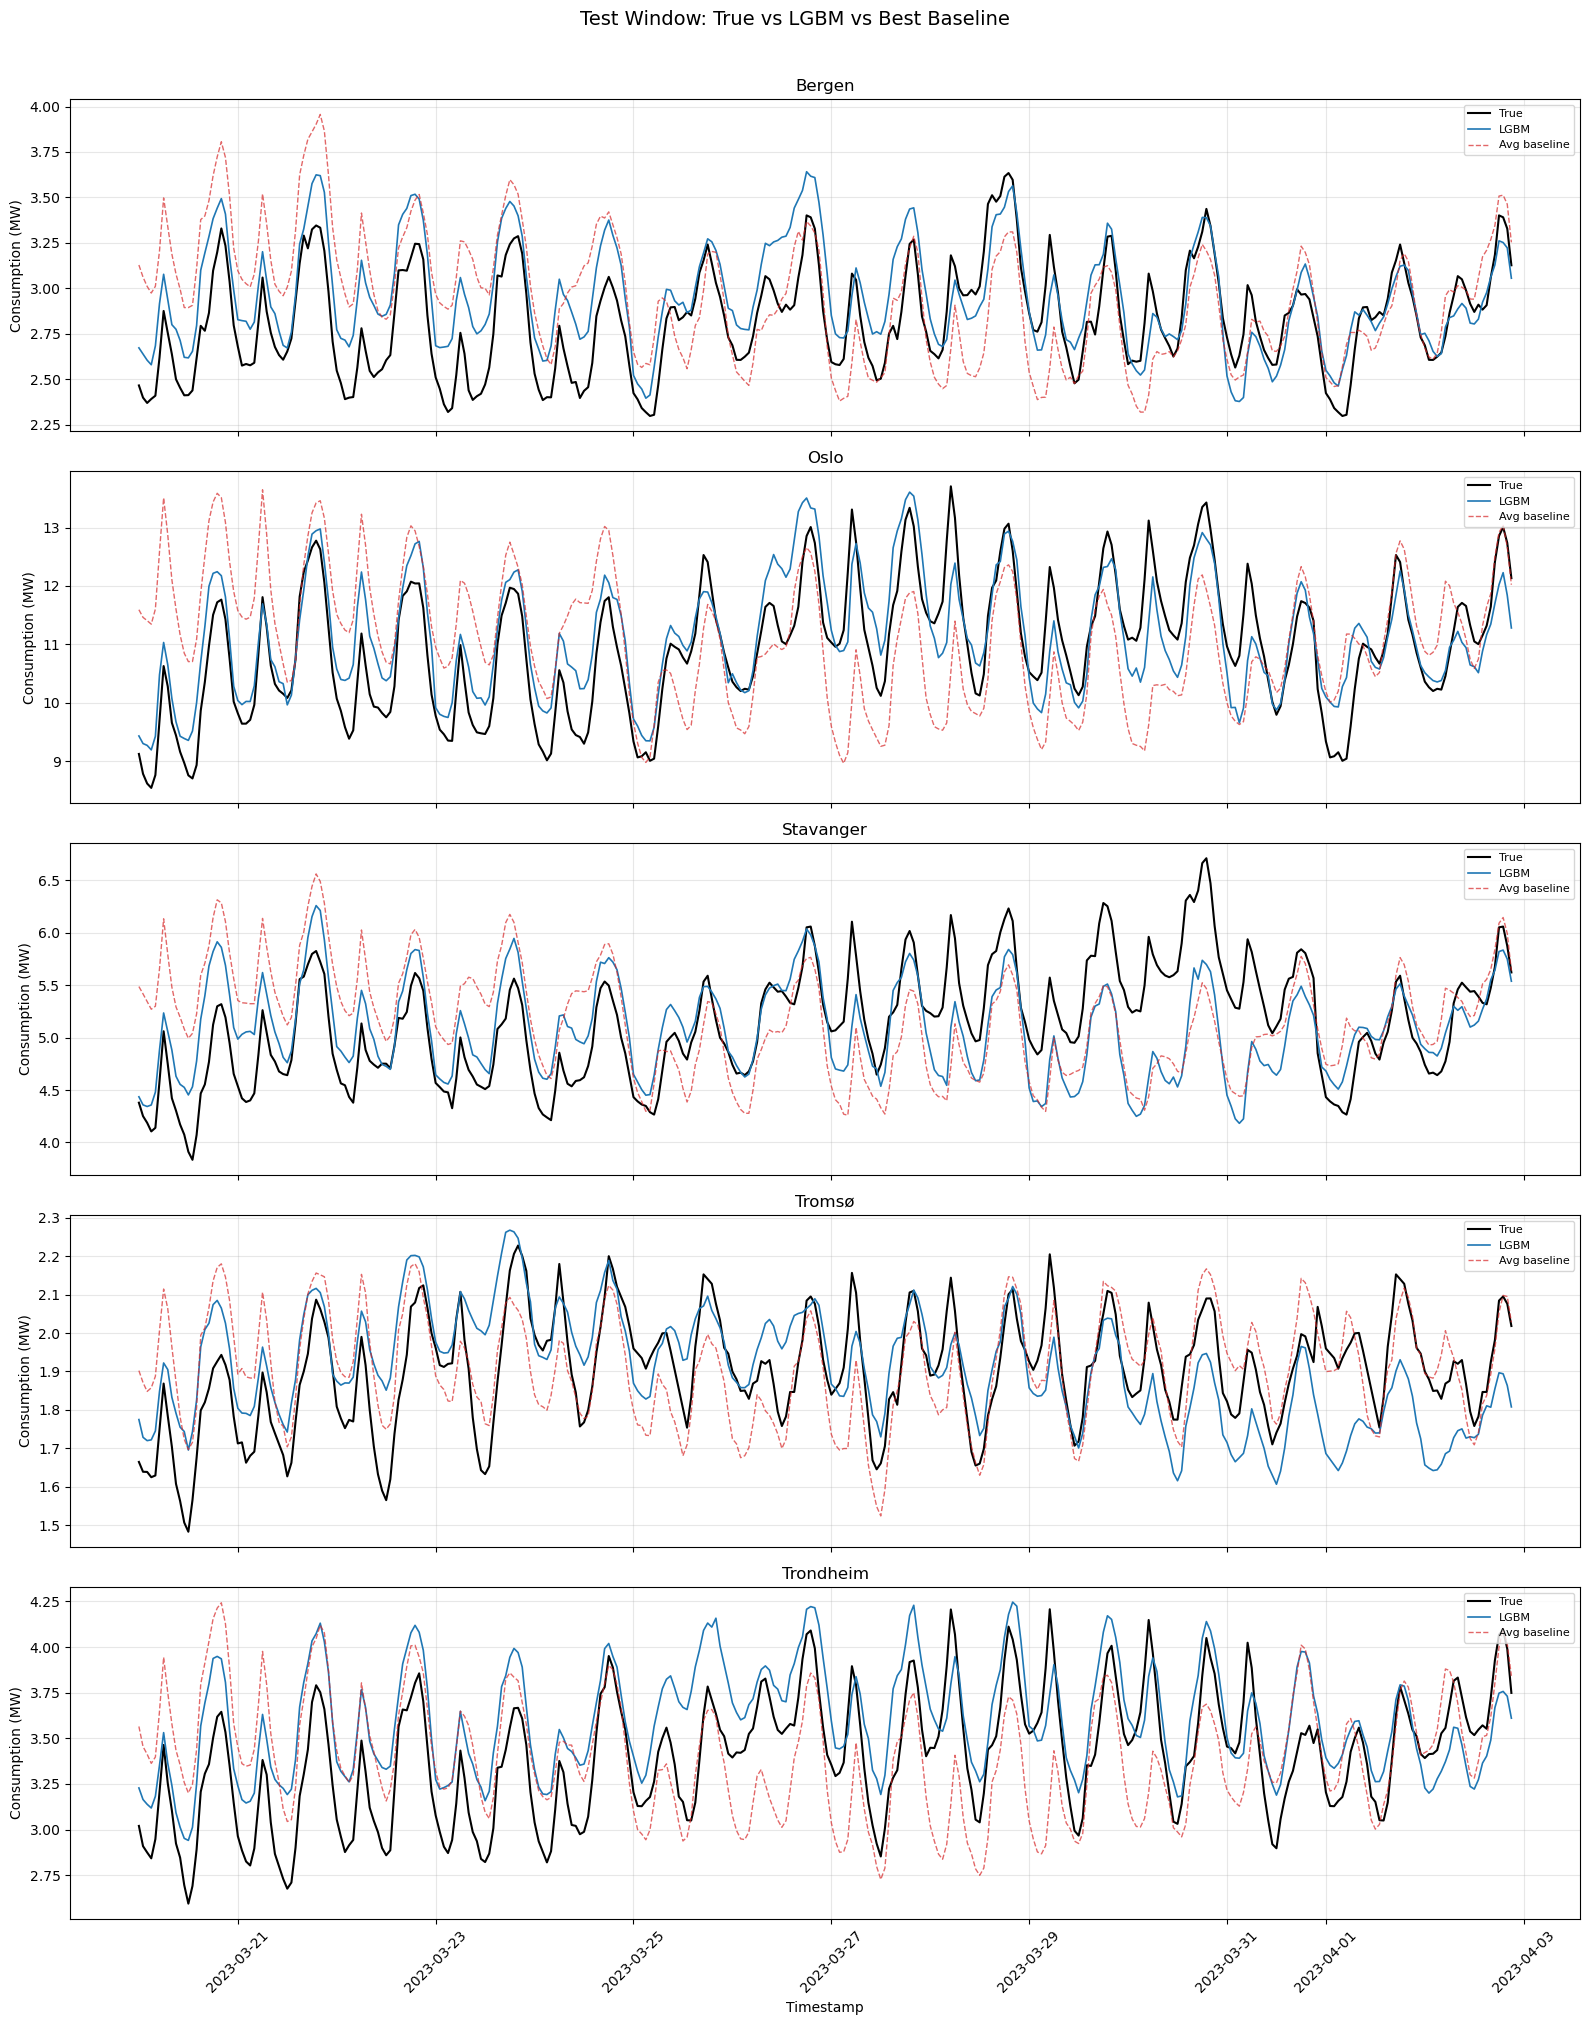

In [37]:
locations = predictions["location"].unique()
best_baseline = avg_preds.rename(columns={"y_pred": "y_pred_baseline"})

fig, axes = plt.subplots(len(locations), 1, figsize=(16, 4 * len(locations)), sharex=True)

for ax, loc in zip(axes, locations):
    loc_pred = predictions[predictions["location"] == loc].sort_values("timestamp")
    loc_base = best_baseline[best_baseline["location"] == loc].sort_values("timestamp")

    ax.plot(loc_pred["timestamp"], loc_pred["y_true_mw"], color="black", label="True", linewidth=1.5)
    ax.plot(loc_pred["timestamp"], loc_pred["y_pred_mw"], color="tab:blue", label="LGBM", linewidth=1.2)
    ax.plot(loc_base["timestamp"], loc_base["y_pred_baseline"], color="tab:red",
            label="Avg baseline", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(loc.capitalize())
    ax.set_ylabel("Consumption (MW)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestamp")
plt.xticks(rotation=45)
plt.suptitle("Test Window: True vs LGBM vs Best Baseline", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

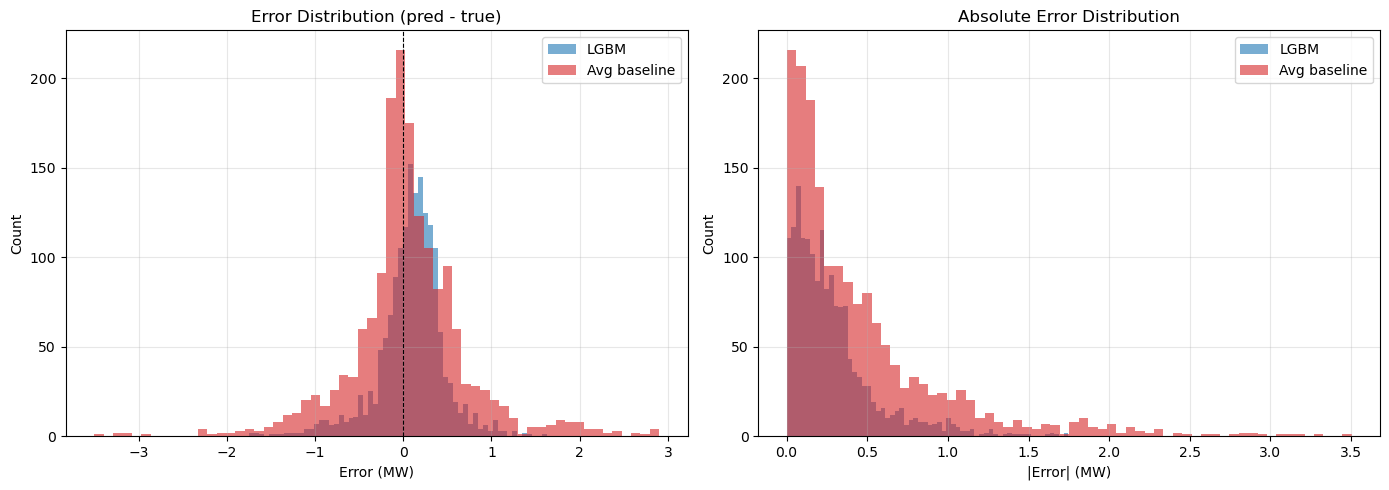

LGBM     — mean error: 0.0879 MW, std: 0.3782
Baseline — mean error: 0.0535 MW, std: 0.6780


In [38]:
err_lgbm = predictions["y_pred_mw"] - predictions["y_true_mw"]
err_base = avg_preds["y_pred"] - avg_preds["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(err_lgbm, bins=60, alpha=0.6, label="LGBM", color="tab:blue")
axes[0].hist(err_base, bins=60, alpha=0.6, label="Avg baseline", color="tab:red")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Error Distribution (pred - true)")
axes[0].set_xlabel("Error (MW)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.abs(err_lgbm), bins=60, alpha=0.6, label="LGBM", color="tab:blue")
axes[1].hist(np.abs(err_base), bins=60, alpha=0.6, label="Avg baseline", color="tab:red")
axes[1].set_title("Absolute Error Distribution")
axes[1].set_xlabel("|Error| (MW)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"LGBM     — mean error: {err_lgbm.mean():.4f} MW, std: {err_lgbm.std():.4f}")
print(f"Baseline — mean error: {err_base.mean():.4f} MW, std: {err_base.std():.4f}")

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/1931639196.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_lgbm = predictions.groupby("hour").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/1931639196.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_base = avg_preds.groupby("hour").apply(lambda g: mae(g["y_true

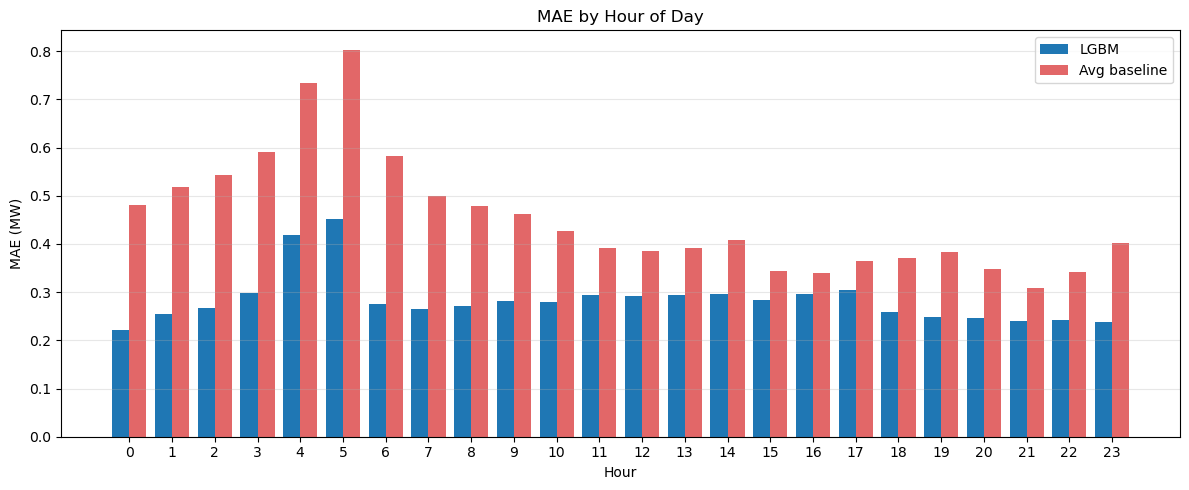

In [39]:
predictions["hour"] = pd.to_datetime(predictions["timestamp"]).dt.hour
avg_preds["hour"] = pd.to_datetime(avg_preds["timestamp"]).dt.hour

hourly_lgbm = predictions.groupby("hour").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
hourly_base = avg_preds.groupby("hour").apply(lambda g: mae(g["y_true"], g["y_pred"]))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_lgbm.index - 0.2, hourly_lgbm.values, width=0.4, label="LGBM", color="tab:blue")
ax.bar(hourly_base.index + 0.2, hourly_base.values, width=0.4, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE (MW)")
ax.set_xticks(range(24))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/2997430889.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/2997430889.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
/var/folders/5j/rf69ky7d5r7c6q9vmn2z2psw0000gn/T/ipykernel_37554/29974

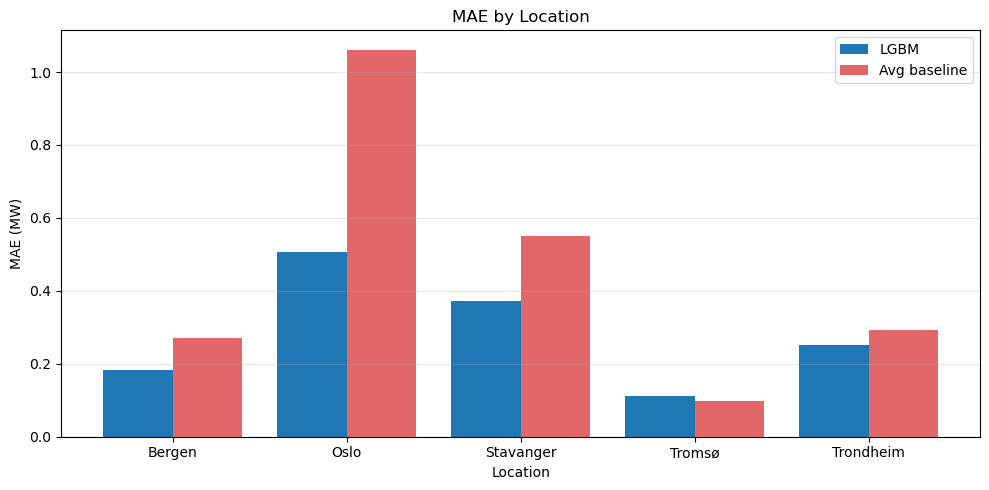

In [40]:
loc_lgbm = predictions.groupby("location").apply(lambda g: mae(g["y_true_mw"], g["y_pred_mw"]))
loc_base = avg_preds.groupby("location").apply(lambda g: mae(g["y_true"], g["y_pred"]))

loc_names = loc_lgbm.index
x = np.arange(len(loc_names))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, loc_lgbm.values, width=0.4, label="LGBM", color="tab:blue")
ax.bar(x + 0.2, loc_base.values, width=0.4, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE by Location")
ax.set_xlabel("Location")
ax.set_ylabel("MAE (MW)")
ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() for n in loc_names])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

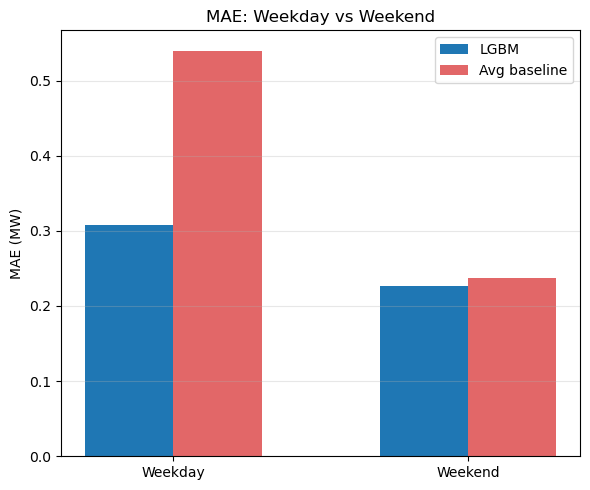

In [41]:
predictions["is_wknd"] = pd.to_datetime(predictions["timestamp"]).dt.dayofweek >= 5
avg_preds["is_wknd"] = pd.to_datetime(avg_preds["timestamp"]).dt.dayofweek >= 5

labels = ["Weekday", "Weekend"]

lgbm_wk = [mae(g["y_true_mw"], g["y_pred_mw"]) for _, g in predictions.groupby("is_wknd")]
base_wk = [mae(g["y_true"], g["y_pred"]) for _, g in avg_preds.groupby("is_wknd")]

x = np.arange(2)
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - 0.15, lgbm_wk, width=0.3, label="LGBM", color="tab:blue")
ax.bar(x + 0.15, base_wk, width=0.3, label="Avg baseline", color="tab:red", alpha=0.7)
ax.set_title("MAE: Weekday vs Weekend")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MAE (MW)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

feature importance

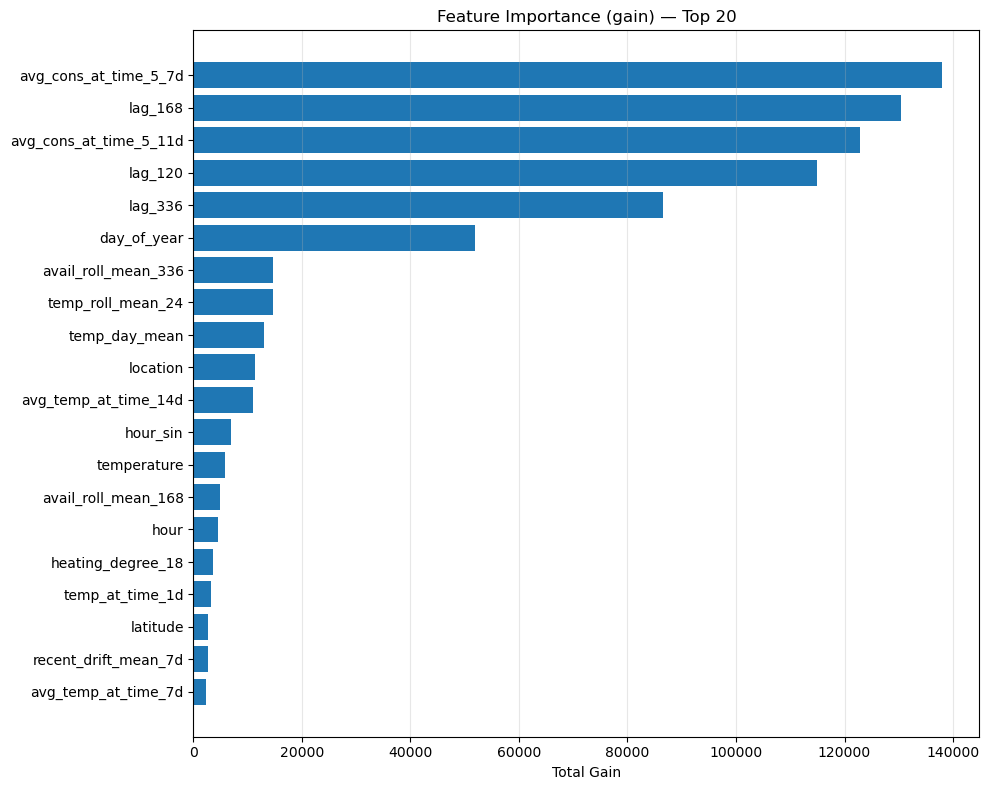

In [42]:
# Retrain on last split to get final feature importance
last = test_splits[-1]

fi_model = make_model({**best_params, "n_estimators": best_n_estimators})
fi_model.fit(last.X_train, last.y_train, categorical_feature=cat_features)

fi_feature_cols = last.X_train.columns.tolist()

imp = pd.DataFrame({
    "feature": fi_feature_cols,
    "gain": fi_model.booster_.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

TOP_N = 20
top = imp.head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top["feature"], top["gain"], color="tab:blue")
ax.set_title(f"Feature Importance (gain) — Top {TOP_N}")
ax.set_xlabel("Total Gain")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()